# 02 — Rapidly-Exploring Random Tree (RRT)

**Section:** Motion Planning · **Mirrors MATLAB:** *RRT Planners for Mobile Robots*

RRT incrementally builds a tree by sampling random points in the configuration space, finding the nearest tree node, and growing a small step toward the sample. This biases the tree to rapidly explore unexplored regions.

We add a **10% goal bias** so the tree occasionally tries to extend toward the goal directly.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

world = 100.0
obstacles = [(30, 30, 15), (60, 70, 12), (75, 30, 10), (20, 70, 8), (50, 45, 8)]
start = np.array([5.0, 5.0])
goal = np.array([95.0, 95.0])


In [2]:
def in_collision(pt, obs):
    for cx, cy, r in obs:
        if (pt[0] - cx) ** 2 + (pt[1] - cy) ** 2 < r * r:
            return True
    return False


def edge_collision(p1, p2, obs, steps=25):
    for t in np.linspace(0, 1, steps):
        if in_collision(p1 * (1 - t) + p2 * t, obs):
            return True
    return False


def rrt(start, goal, obs, world=100.0, max_iter=3000, step=4.0, goal_bias=0.1, goal_tol=4.0):
    tree = [start]
    parent = {0: -1}
    for _ in range(max_iter):
        rnd = goal if np.random.random() < goal_bias else np.random.uniform(0, world, 2)
        dists = [np.linalg.norm(p - rnd) for p in tree]
        i_near = int(np.argmin(dists))
        near = tree[i_near]
        direction = rnd - near
        d = np.linalg.norm(direction)
        new = near + (direction / d) * step if d > step else rnd
        if in_collision(new, obs) or edge_collision(near, new, obs):
            continue
        tree.append(new)
        parent[len(tree) - 1] = i_near
        if np.linalg.norm(new - goal) < goal_tol:
            tree.append(goal)
            parent[len(tree) - 1] = len(tree) - 2
            return tree, parent, True
    return tree, parent, False


tree, parent, success = rrt(start, goal, obstacles)
print(f"Success: {success}  ·  tree size: {len(tree)} nodes")


Success: True  ·  tree size: 88 nodes


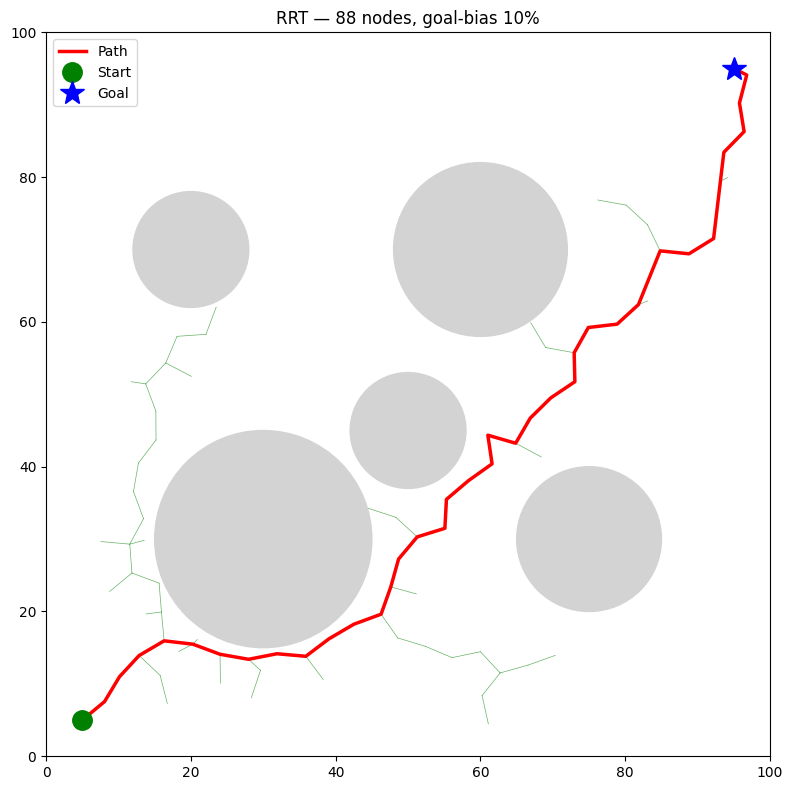

In [3]:
fig, ax = plt.subplots(figsize=(8, 8))
for cx, cy, r in obstacles:
    ax.add_patch(plt.Circle((cx, cy), r, color='lightgrey'))
for idx, p_idx in parent.items():
    if p_idx >= 0:
        ax.plot([tree[idx][0], tree[p_idx][0]], [tree[idx][1], tree[p_idx][1]],
                'g-', lw=0.5, alpha=0.6)
if success:
    path, idx = [], len(tree) - 1
    while idx != -1:
        path.append(tree[idx])
        idx = parent[idx]
    path = np.array(path[::-1])
    ax.plot(path[:, 0], path[:, 1], 'r-', lw=2.5, label='Path')
ax.plot(*start, 'go', markersize=14, label='Start')
ax.plot(*goal, 'b*', markersize=18, label='Goal')
ax.set_xlim(0, world); ax.set_ylim(0, world); ax.set_aspect('equal')
ax.legend(loc='upper left')
ax.set_title(f'RRT — {len(tree)} nodes, goal-bias 10%')
plt.tight_layout()
plt.show()


## Notes

- **RRT\*** rewires the tree on each insertion to converge toward an optimal path.
- **BiRRT** grows two trees (one from start, one from goal) and tries to connect them — usually faster in cluttered spaces.
- The goal-bias parameter trades exploration vs exploitation.
